In [1]:
!hostname

gnode011.cluster


In [2]:
!nvidia-smi

Wed Apr 16 19:53:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:31:00.0 Off |                    0 |
| N/A   28C    P0             41W /  300W |       1MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import itertools as it
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sdeint
from toolbox import (
    make_loss,
    StatLoss,
    SINN,
    FPU
)
import time

In [4]:
torch.cuda.is_available()

True

In [5]:
device = torch.device('cuda')

In [6]:
print(torch.__version__)
print(torch.version.cuda)

2.0.1+cu118
11.8


In [7]:
seed = 1234
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

In [8]:
from scipy.signal import argrelextrema

# Parameters
A = 0.02                   # Driving strength

def f(x):
    return -0.5 * x**2 + 0.25 * x**4 - A * x

# Parameters
x_range = np.linspace(-2, 2, 1000)  # High resolution to capture small changes

# Calculate function values
y = f(x_range)

# Find local minima and maxima
maxima_indices = argrelextrema(y, np.greater)[0]
minima_indices = argrelextrema(y, np.less)[0]
print(maxima_indices)
print(minima_indices)

[495]
[252 752]


In [9]:
minima_indices[0]

252

A: ( -0.9909909909909911 , -0.23009974748140966 )
B: ( -0.018018018018018056 , 0.00019806222295051527 )
C: ( 1.011011011011011 , -0.27009763918080865 )


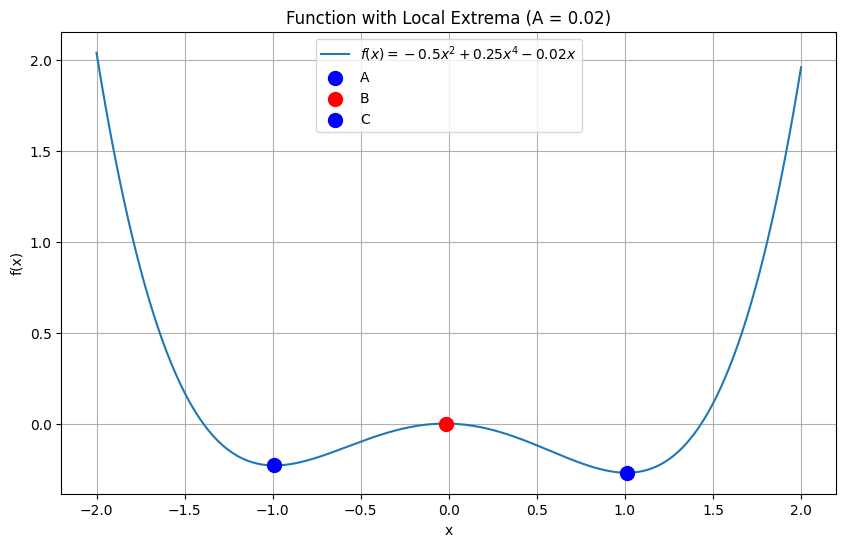

In [10]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_range, y, label=r'$f(x) = -0.5x^2 + 0.25x^4 - 0.02x$')

# Mark extrema
plt.scatter(x_range[minima_indices[0]], y[minima_indices[0]], 
            color='blue', s=100, label='A', zorder=5)
print('A: (',x_range[minima_indices[0]],',',y[minima_indices[0]],')')
plt.scatter(x_range[maxima_indices[0]], y[maxima_indices[0]], 
            color='red', s=100, label='B', zorder=5)
print('B: (',x_range[maxima_indices[0]],',',y[maxima_indices[0]],')')
plt.scatter(x_range[minima_indices[1]], y[minima_indices[1]], 
            color='blue', s=100, label='C', zorder=5)
print('C: (',x_range[minima_indices[1]],',',y[minima_indices[1]],')')
plt.title('Function with Local Extrema (A = 0.02)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

$<\tau>=\dfrac1D \dfrac{2\pi k_B T}{m\omega_a \omega_b}e^{\beta E^{+}_b}$

$D=\dfrac{k_B T}{\gamma}$ 

$\omega_a = \sqrt{\dfrac{U''(x_a)}{m}}$, $\omega_b = \sqrt{\dfrac{U''(x_b)}{m}}$ 

$E^{+}_b=U_B-U_A$

thermal energy: $k_B T << E^{+}_b$

$\beta = \dfrac{1}{k_B T}$

$<\tau>= \dfrac{2\pi \gamma}{\sqrt{U''(x_a)} \sqrt{U''(x_b)} }e^{\beta E^{+}_b}$


In [11]:
E_b = y[maxima_indices[0]] - y[minima_indices[0]]
E_b 

0.23029780970436017

$E^{+}_b=0.23029780970436017$

In [12]:
thermal_energy = E_b/5
thermal_energy

0.04605956194087203

$k_B T = 0.04605956194087203$

In [13]:
print(y[maxima_indices[0]] - y[minima_indices[1]])

0.27029570140375914


$E^{-}_b=0.27029570140375914$

So we have $k_B T<<E^{+}_b<E^{-}_b$

In [14]:
def d2V_dx2(x):
    return -1 + 3 * x**2

In [15]:
d2V_dx2_a = d2V_dx2(x_range[minima_indices[0]])
d2V_dx2_a

1.94618943267592

In [16]:
d2V_dx2_b = d2V_dx2(x_range[maxima_indices[0]])
d2V_dx2_b

-0.9990260530801072

In [17]:
# Parameters
D = 1/20                   # Fluctuation strength
gamma = thermal_energy/D                # Damping coefficient
beta = 1.0/thermal_energy

In [18]:
gamma

0.9211912388174406

In [19]:
beta

21.711018469600912

In [20]:
tau = 2*np.pi*gamma/np.sqrt(abs(d2V_dx2_a))/np.sqrt(abs(d2V_dx2_b))*np.exp(beta*E_b)
tau

616.0573092061182

In [21]:
# Parameters
T = 10 * tau               # Period 
Omega = 2 * np.pi / T      # Frequency of the oscillation

dt= 0.01                  # Step-size of the SDE solver 
delta_t= T/20              # Step-size of the temporally coarse-grained path
sec_length = 400           # Length of the input sequence
batch = 400                # Batch size 

In [22]:
T

6160.573092061182

In [23]:
delta_t

308.0286546030591

In [24]:
# Potential function and its derivative
def V(x, t):
    return -0.5 * x**2 + 0.25 * x**4 - A * x * np.sin(Omega * t)

def dV_dx(x, t):
    return -x + x**3 - A * np.sin(Omega * t)

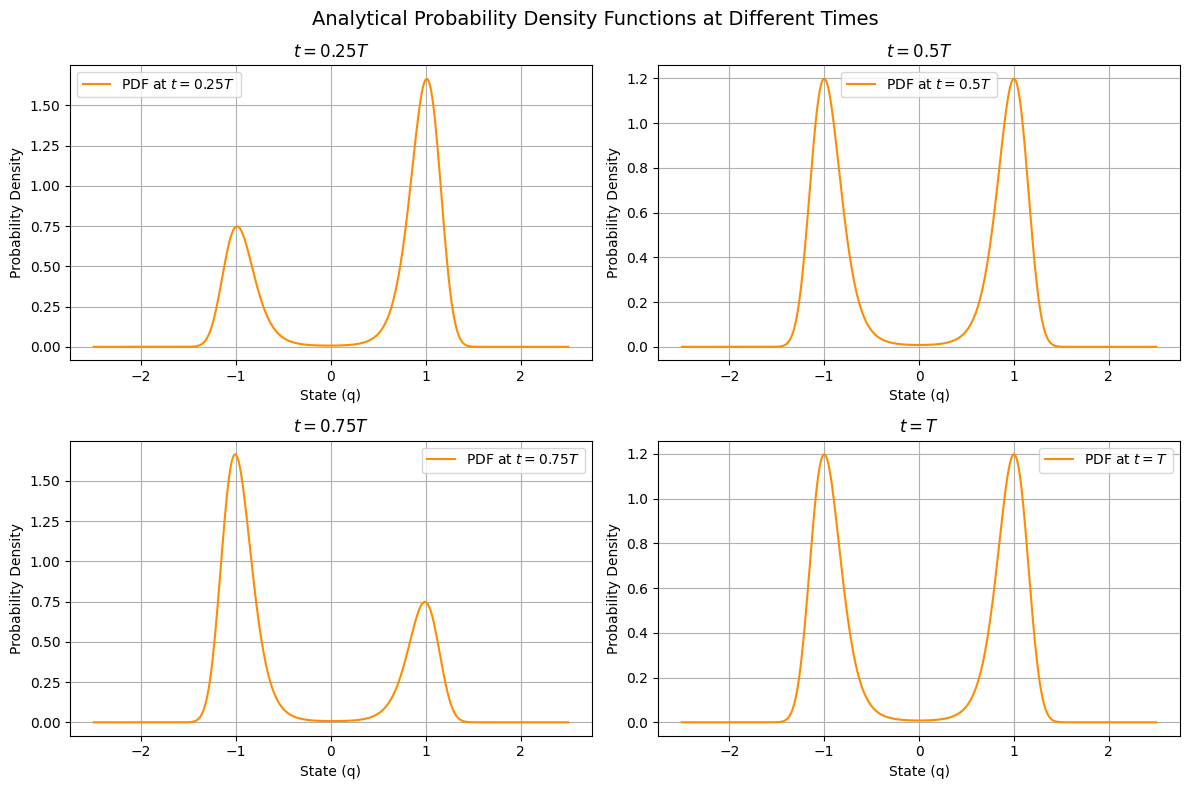

In [25]:
from scipy.integrate import quad


# Define x-range for normalization
x = np.linspace(-2.5, 2.5, sec_length)

# Compute the unnormalized PDF over the x-range
def analytical_pdf(x, t):
    potential = V(x, t)
    unnormalized = np.exp(-potential / D)
    Z = np.trapz(unnormalized, x)
    return unnormalized/Z

# Time points to evaluate
time_points = [0.25 * T, 0.5 * T, 
               0.75 * T, 1.0 * T]
# time_points = [0.5 * np.pi/Omega, 1.0 * np.pi/Omega, 
#                1.5 * np.pi/Omega, 2.0 * np.pi/Omega]
titles = [r'$t = 0.25T$', r'$t = 0.5T$', 
          r'$t = 0.75T$', r'$t = T$']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Analytical Probability Density Functions at Different Times', fontsize=14)
axes = axes.flatten()  # Flatten for easy iteration

for i, (t, title) in enumerate(zip(time_points, titles)):
    pdf = analytical_pdf(x, t)
    axes[i].plot(x, pdf, color='darkorange', label=f'PDF at {title}')
    axes[i].set_xlabel("State (q)")
    axes[i].set_ylabel("Probability Density")
    axes[i].set_title(title)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [26]:
%%time


### SDE solver (EM scheme), 
Time = 5*delta_t*sec_length
print(Time)
length=int(Time/dt)+1
t = np.linspace(0, Time, length) # define time axis
gap=int(delta_t/dt)
t_store=t[0:-1:gap]
q_store = np.zeros([t_store.size+1,batch])


# Set initial condition based on probabilities
q = np.zeros((2, batch))
q[0, :] = 1

# Solve SDE using Euler Maruyama scheme
j=1
for i in range(1,length):
     q[1,:] = q[0,:] - dV_dx(q[0,:],i*dt)*dt + np.random.randn(1,batch)*np.sqrt(2*dt*D)
     
     if i % gap ==0:            
        q_store[j,:]=q[1,:]
        j=j+1
    
     q[0,:]=q[1,:]

Toss=int(t_store.size/2)          
q_store=q_store[Toss:-1,:]         
print(q_store.shape)



616057.3092061182
(1001, 400)
CPU times: user 55min 57s, sys: 64.1 ms, total: 55min 57s
Wall time: 56min 5s


Text(0.5, 1.0, 'Solution of the Transtion dynamics')

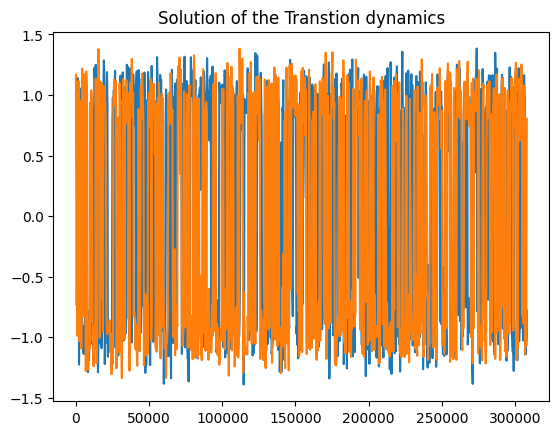

In [27]:
plt.figure(1)
for i in range(2):
    plt.plot(t_store[Toss:]-t_store[Toss],q_store[:,i])
# plt.legend()
plt.title("Solution of the Transtion dynamics")

In [28]:
#####################  Construct the sample traj for SINN learning 
ini=np.random.randn(sec_length,batch)
Traj=q_store[-sec_length:,:]
Time_seq=np.arange(len(Traj[:,1]))*delta_t
print(ini.shape, Traj.shape)

(400, 400) (400, 400)


In [29]:
# Reformulating data into Torch tensors 
# Input of SINN should be of the form (seq_len, batch, input_size)

ini = np.random.randn(2*sec_length,batch).astype(np.float32) 
input = torch.from_numpy(ini.reshape(2*sec_length, batch,1)).to(device)
batch_validation = batch
val_set = torch.normal(0.0, 1.0, (2*sec_length, batch_validation, 1), device=device)

# input of the LSTM should be of the form (seq_len, batch, input_size)
Traj = Traj.astype(np.float32) 
target = torch.from_numpy(Traj.reshape(sec_length, batch, 1)).to(device)

print('The torch input size is', input.size(), input.dtype)
print('The torch validation size is', val_set.size(), val_set.dtype)
print('The torch target size is', target.size(), target.dtype)

The torch input size is torch.Size([800, 400, 1]) torch.float32
The torch validation size is torch.Size([800, 400, 1]) torch.float32
The torch target size is torch.Size([400, 400, 1]) torch.float32


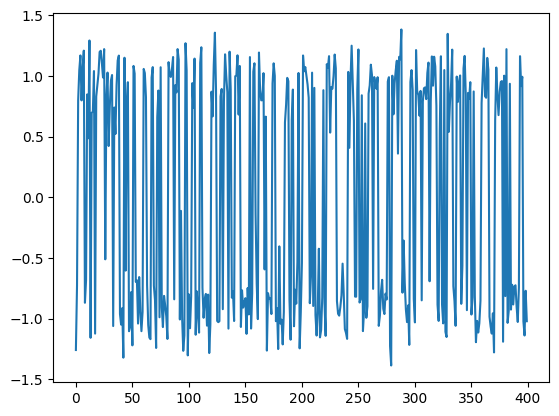

In [30]:
plt.plot(Traj[:,0])

In [31]:
start = 5
step = 20
indices = torch.arange(start, 400, step)

In [32]:
Traj_1 = Traj[indices,:]

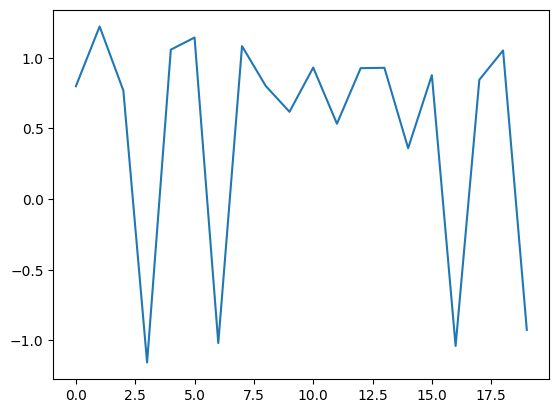

In [33]:
plt.plot(Traj_1[:,0])

In [34]:
Traj_1 = torch.from_numpy(Traj_1.reshape(20, batch, 1)).to(device)

In [53]:
# Defining Loss functions
N = 400
loss_pdf_empirical1 = make_loss('pdf', Traj_1, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

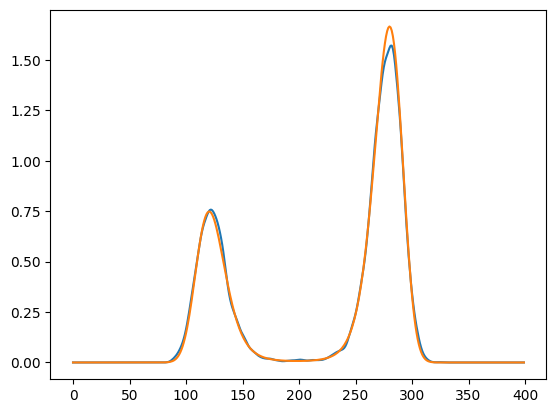

In [54]:
plt.plot(loss_pdf_empirical1._target.cpu())
pdf = analytical_pdf(x, 0.25*T)
plt.plot(pdf)

In [37]:
start = 10
step = 20
indices = torch.arange(start, 400, step)
Traj_2 = Traj[indices,:]

In [38]:
Traj_2 = torch.from_numpy(Traj_2.reshape(20, batch, 1)).to(device)

In [51]:
loss_pdf_empirical2 = make_loss('pdf', Traj_2, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

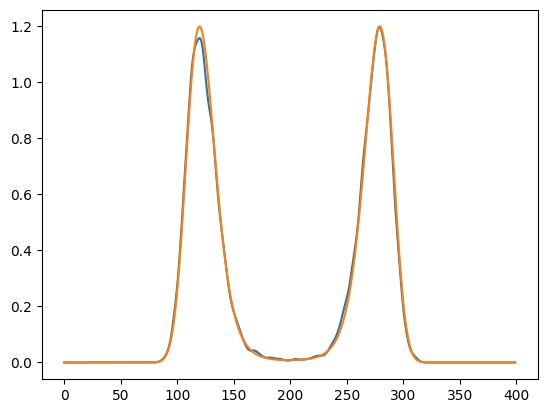

In [52]:
plt.plot(loss_pdf_empirical2._target.cpu())
pdf = analytical_pdf(x, 0.5*T)
plt.plot(pdf)

In [41]:
start = 15
step = 20
indices = torch.arange(start, 400, step)
Traj_3 = Traj[indices,:]

In [42]:
Traj_3 = torch.from_numpy(Traj_3.reshape(20, batch, 1)).to(device)

In [55]:
loss_pdf_empirical3 = make_loss('pdf', Traj_3, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

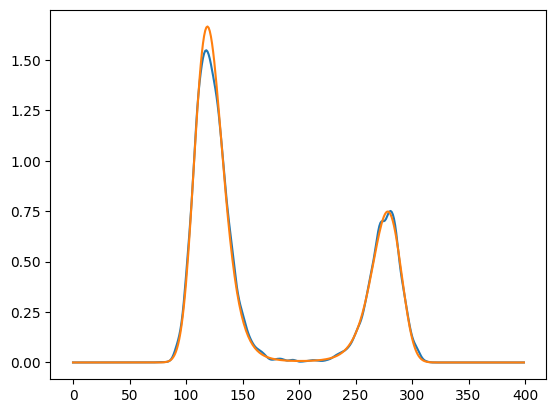

In [56]:
plt.plot(loss_pdf_empirical3._target.cpu())
pdf = analytical_pdf(x, 0.75*T)
plt.plot(pdf)

In [45]:
start = 0
step = 20
indices = torch.arange(start, 400, step)
Traj_4 = Traj[indices,:]

In [46]:
Traj_4 = torch.from_numpy(Traj_4.reshape(20, batch, 1)).to(device)

In [49]:
loss_pdf_empirical4 = make_loss('pdf', Traj_4, lower=-2.5, upper=2.5, n=N, bw=0.2, device=device)

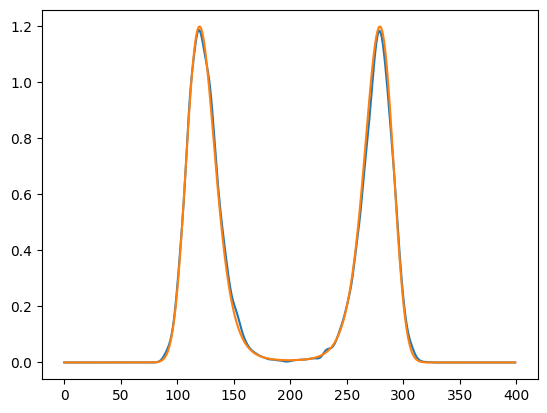

In [50]:
plt.plot(loss_pdf_empirical4._target.cpu())
pdf = analytical_pdf(x, T)
plt.plot(pdf)

In [ ]:
## Calculating the acf for q(t) by brutal force
Traj1=q_store
T_acf=t_store[0:Traj1.shape[0]]
acf_u=StatLoss.acf(torch.from_numpy(Traj1.reshape(Traj1.shape[0], batch,1)),method='bruteforce')
acf_u_fft=StatLoss.acf(torch.from_numpy(Traj1.reshape(Traj1.shape[0], batch,1)))
corr_u=acf_u.mean(axis=1).detach().cpu().numpy()
corr_u_fft=acf_u_fft.mean(axis=1).detach().cpu().numpy()
plt.figure(1)      
plt.plot(T_acf, corr_u,'b',label='Brutal force')
plt.plot(T_acf, corr_u_fft,'g--',label='FFT')
plt.title('ACF of q(t)')
plt.xlim([0,T_acf[-1]/2])
plt.legend()
plt.show()

In [ ]:
#####################  Construct the sample traj for SINN learning 
ini=np.random.randn(sec_length,batch)
Traj=q_store[-sec_length:,:]
T=np.arange(len(Traj[:,1]))*delta_t
print(ini.shape, Traj.shape)

In [ ]:
# Reformulating data into Torch tensors 
# Input of SINN should be of the form (seq_len, batch, input_size)

ini = np.random.randn(2*sec_length,batch).astype(np.float32) 
input = torch.from_numpy(ini.reshape(2*sec_length, batch,1)).to(device)
batch_validation = batch
val_set = torch.normal(0.0, 1.0, (2*sec_length, batch_validation, 1), device=device)

# input of the LSTM should be of the form (seq_len, batch, input_size)
Traj = Traj.astype(np.float32) 
target = torch.from_numpy(Traj.reshape(sec_length, batch, 1)).to(device)
PDF_exact=torch.from_numpy(pdf_exact).to(device)
print('The torch input size is', input.size(), input.dtype)
print('The torch validation size is', val_set.size(), val_set.dtype)
print('The torch target size is', target.size(), target.dtype)

In [ ]:
# Defining Loss functions

LAGS = 400
N = sec_length
# loss_acf_fft = make_loss('acf[fft]', target, lags=LAGS, device=device)
# loss_acf_q2 = make_loss('acf[fft]', target**2, lags=LAGS, device=device)
# loss_acf_bruteforce = make_loss('acf[bruteforce]', target, lags=LAGS, device=device)
# loss_acf_randbrute = make_loss('acf[randombrute]', target, lags=LAGS, sample_lags=20, device=device)
loss_pdf_empirical = make_loss('pdf', target, lower=-2.5, upper=2.5, n=N, bw=0.1, device=device)
# loss_pdf_exact = make_loss('pdf', PDF_exact, lower=-5, upper=5, n=N, bw=None, device=device)

In [ ]:
plt.plot(x, pdf_exact, 'r')
plt.plot(x, loss_pdf_empirical._target.cpu(),'b--')

In [ ]:
pdf = loss_pdf_empirical._target.cpu()

In [ ]:
# Flatten the pdf tensor to 1D
pdf = pdf.flatten()
# Define the grid bounds and number of points
lower = -2.5  # Lower bound of the grid
upper = 2.5    # Upper bound of the grid
n = pdf.shape[0]  # Number of grid points

# Compute the grid spacing
grid_spacing = (upper - lower) / (n - 1)

# Compute the AUC using the trapezoidal rule
auc = torch.trapz(pdf, dx=grid_spacing)

print(f"Area under the curve (AUC): {auc.item()}")

In [ ]:
# Compute the AUC using the trapezoidal rule
auc_exact = np.trapz(pdf_exact, dx=grid_spacing)

In [ ]:
auc_exact

In [ ]:
pdf_exact_np = np.array(pdf_exact)
pdf_empirical_np = np.array(pdf)
pdf_exact_np = pdf_exact_np.reshape(pdf_empirical_np.shape)

# Compute the difference
difference = pdf_exact_np - pdf_empirical_np

# Compute the L2 norm of the difference
l2_norm = np.linalg.norm(difference, ord=2)

print("L2 norm of the difference:", l2_norm)

In [ ]:
plt.plot(difference)